In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import anndata as ad

SEED = 42
CELLS_PER_DAY_BATCH_ARM = 500
N_HVG = 2_000
N_PCS_FIT = 50
N_PCS_MODEL = 30



In [2]:
adata = ad.read_h5ad("/Users/joshuayang/Projects/Data_CellStateAdj/wot_schiebinger2019_full.h5ad")

In [3]:

# ============================================================
# 1. Basic validation
# ============================================================

assert adata.n_obs == 236_285
assert adata.n_vars == 19_089
assert adata.obs_names.is_unique, "Cell IDs must be unique."
assert adata.var_names.is_unique, "Gene names must be unique."

# Keep the large matrix sparse.
if sp.issparse(adata.X):
    adata.X = adata.X.tocsr(copy=False)
    expression_values = adata.X.data
else:
    expression_values = np.asarray(adata.X).ravel()

assert np.isfinite(expression_values).all(), "Expression matrix contains NaN/Inf."
assert expression_values.min(initial=0) >= 0, (
    "Expected a nonnegative log-normalized expression matrix."
)

# Do NOT run normalize_total() or log1p().
print("Expression range:", expression_values.min(), expression_values.max())
print("Matrix shape:", adata.shape)


Expression range: 0.50693613 8.314803
Matrix shape: (236285, 19089)


In [4]:

# ============================================================
# 2. Standardize metadata types
# ============================================================

def to_boolean(series):
    """Handle bool, categorical, or string True/False columns."""
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False).to_numpy()

    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .isin(["true", "1", "yes"])
        .to_numpy()
    )


adata.obs["day"] = pd.to_numeric(adata.obs["day"], errors="raise")
adata.obs["batch"] = adata.obs["batch"].astype(str).astype("category")

serum_flag = to_boolean(adata.obs["serum"])
two_i_flag = to_boolean(adata.obs["2i"])
day = adata.obs["day"].to_numpy()

In [5]:
# ============================================================
# 3. Convert the two Boolean columns into an explicit arm
#
# Before/at day 8: one shared population
# After day 8: serum or 2i
# ============================================================

arm = np.full(adata.n_obs, "invalid", dtype=object)

pre_split = day <= 8.0
post_split = day > 8.0

arm[pre_split] = "shared"

arm[
    post_split
    & serum_flag
    & ~two_i_flag
] = "serum"

arm[
    post_split
    & two_i_flag
    & ~serum_flag
] = "2i"

if np.any(arm == "invalid"):
    bad = adata.obs.loc[arm == "invalid", ["day", "serum", "2i"]]
    raise ValueError(
        f"Found {len(bad)} cells with unexpected condition flags.\n"
        f"{bad.head()}"
    )

adata.obs["arm"] = pd.Categorical(
    arm,
    categories=["shared", "serum", "2i"],
)

print(
    adata.obs.groupby(
        ["day", "batch", "arm"],
        observed=True,
    ).size()
)



day   batch  arm   
0.0   1      shared    3433
      2      shared    1123
0.5   1      shared    1220
      2      shared    2229
1.0   1      shared    1343
                       ... 
17.5  2      2i        2412
18.0  1      serum     1897
             2i        1989
      2      serum     1902
             2i        1648
Length: 122, dtype: int64


In [6]:

# ============================================================
# 4. Balanced subsampling for the first experiment
#
# Before day 8: sample per day × batch
# After day 8: sample per day × batch × arm
#
# Because 'arm=shared' is a single category, pre-day-8 cells
# are sampled once rather than duplicated.
# ============================================================

def balanced_subsample(
    adata,
    group_columns,
    max_cells_per_group=500,
    random_state=42,
):
    rng = np.random.default_rng(random_state)
    selected_positions = []

    groups = adata.obs.groupby(
        group_columns,
        observed=True,
        sort=True,
    ).indices

    for _, positions in groups.items():
        positions = np.asarray(positions, dtype=int)
        n_select = min(max_cells_per_group, len(positions))

        selected_positions.append(
            rng.choice(
                positions,
                size=n_select,
                replace=False,
            )
        )

    selected_positions = np.concatenate(selected_positions)
    sampled = adata[selected_positions].copy()

    # Convenient deterministic ordering for downstream work.
    order = np.lexsort(
        (
            sampled.obs_names.astype(str).to_numpy(),
            sampled.obs["batch"].astype(str).to_numpy(),
            sampled.obs["day"].to_numpy(),
        )
    )

    return sampled[order].copy()


adata_balanced = balanced_subsample(
    adata,
    group_columns=["day", "batch", "arm"],
    max_cells_per_group=CELLS_PER_DAY_BATCH_ARM,
    random_state=SEED,
)

print("Balanced union:", adata_balanced.shape)
print(
    adata_balanced.obs.groupby(
        ["arm"],
        observed=True,
    ).size()
)


Balanced union: (60817, 19089)
arm
shared    16817
serum     22000
2i        22000
dtype: int64


In [7]:


# ============================================================
# 5. Select highly variable genes
#
# The downloaded matrix is already log-normalized, so use
# flavor='seurat', not flavor='seurat_v3'.
#
# Batch is used only to make HVG selection batch-aware.
# Do not use day or arm as batch variables.
# ============================================================

mitochondrial = (
    adata_balanced.var_names
    .str.upper()
    .str.startswith("MT-")
)

adata_balanced.var["mitochondrial"] = mitochondrial

# Exclude mitochondrial genes before HVG selection.
hvg_input = adata_balanced[
    :,
    ~adata_balanced.var["mitochondrial"],
].copy()

sc.pp.highly_variable_genes(
    hvg_input,
    flavor="seurat",
    n_top_genes=N_HVG,
    batch_key="batch",
    subset=False,
    inplace=True,
)

hvg_names = hvg_input.var_names[
    hvg_input.var["highly_variable"]
]

print("Selected HVGs:", len(hvg_names))



Selected HVGs: 2000


In [8]:

# ============================================================
# 6. Prepare the frozen expression representation
# ============================================================

adata_rep = adata_balanced[:, hvg_names].copy()

# Preserve the original log-normalized HVG matrix.
adata_rep.layers["lognorm"] = adata_rep.X.copy()

# This intentionally creates a dense matrix. At approximately
# 60,000 cells × 2,000 genes, expect several hundred MB.
sc.pp.scale(
    adata_rep,
    zero_center=True,
    max_value=10,
)

sc.pp.pca(
    adata_rep,
    n_comps=N_PCS_FIT,
    zero_center=True,
    svd_solver="randomized",
    random_state=SEED,
)

# Coordinates to be frozen and used by the planned model.
adata_rep.obsm["X_model"] = (
    adata_rep.obsm["X_pca"][:, :N_PCS_MODEL]
    .astype(np.float32)
    .copy()
)

print("PCA coordinates:", adata_rep.obsm["X_pca"].shape)
print("Model coordinates:", adata_rep.obsm["X_model"].shape)


/Users/joshuayang/miniconda3/envs/LCL/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


PCA coordinates: (60817, 50)
Model coordinates: (60817, 30)


In [9]:
# ============================================================
# 7. Extract the serum trajectory
#
# Includes:
#   - shared cells through day 8
#   - serum cells after day 8
# ============================================================

serum_mask = adata_rep.obs["arm"].isin(["shared", "serum"])
adata_serum = adata_rep[serum_mask].copy()

assert adata_serum.obs["day"].nunique() == 39
assert sorted(adata_serum.obs["day"].unique()) == sorted(
    adata.obs["day"].unique()
)

print("Serum model dataset:", adata_serum.shape)
print("Serum time points:", adata_serum.obs["day"].nunique())
print(
    adata_serum.obs.groupby(
        ["day", "batch", "arm"],
        observed=True,
    ).size()
)


Serum model dataset: (38817, 2000)
Serum time points: 39
day   batch  arm   
0.0   1      shared    500
      2      shared    500
0.5   1      shared    500
      2      shared    500
1.0   1      shared    500
                      ... 
17.0  2      serum     500
17.5  1      serum     500
      2      serum     500
18.0  1      serum     500
      2      serum     500
Length: 78, dtype: int64


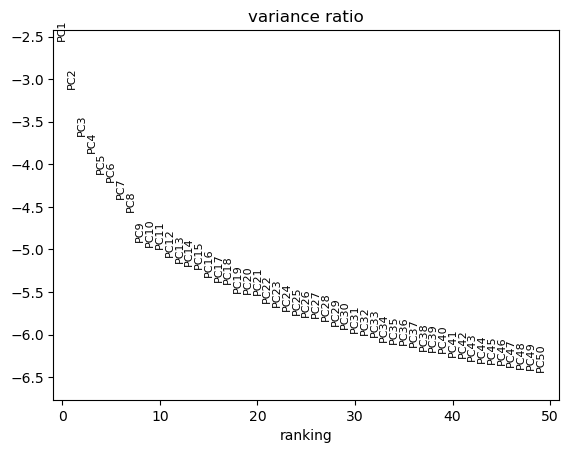

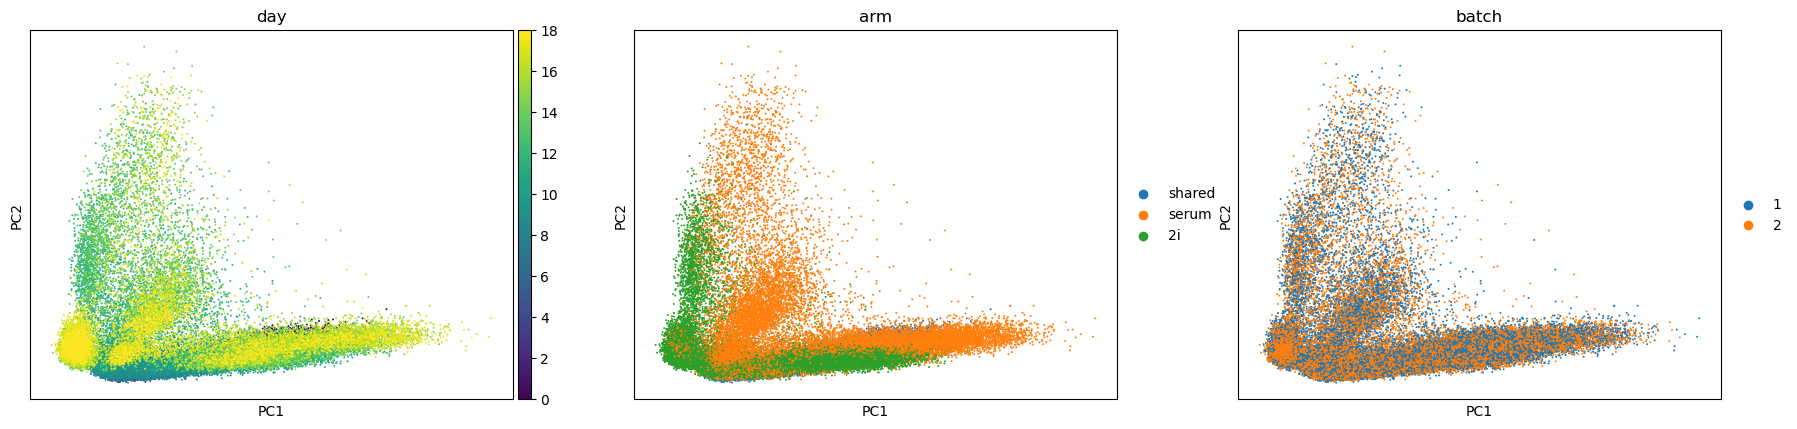

In [10]:

# ============================================================
# 8. Basic PCA diagnostics
# ============================================================

sc.pl.pca_variance_ratio(
    adata_rep,
    n_pcs=N_PCS_FIT,
    log=True,
)

sc.pl.pca(
    adata_rep,
    color=["day", "arm", "batch"],
    size=8,
)

# Optional: save the frozen representation.
adata_rep.write_h5ad(
    "wot_balanced_shared_pca.h5ad",
    compression="gzip",
)

adata_serum.write_h5ad(
    "wot_serum_first_run_pca.h5ad",
    compression="gzip",
)